<a href="https://colab.research.google.com/github/cnsalsabila/myXLSentimentAnalysis/blob/main/Week%202-3/EDA_myXLReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WEEK 3 EDA for myXL Review


# Exploratory Data Analysis (EDA) of JKN Reviews

## 1. Install Necessary Packages
This section ensures that all required Python packages are installed before running the notebook.

In [20]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries
We import essential libraries for data analysis, visualization, and text processing.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

# 3. Load Dataset

In [22]:
# Read the Excel file (only if the file exists)
df_myxlrev = pd.read_csv("df_myxl_rev.csv")

# Display the first few rows
df_myxlrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c8a2d9e1-12f1-480e-b813-da982356f41b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sy beli kartu perdana e-sim d myxl harga 35.00...,1.0,0.0,9.1.0,2026-04-02 14:13:51,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-04-02 15:00:43,9.1.0
1,922fd588-0a16-483a-af36-dceab1f818db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tolong myxl,KOUTA SAYA AWAL NYA 57GB,KO BISA S...",1.0,0.0,9.1.0,2026-04-02 14:13:35,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-04-02 15:00:45,9.1.0
2,a1ee69f9-82c8-4d4d-a3b9-a27fe8141546,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"knp xl gak sehebat dl,sinyal gak jelas apalagi...",5.0,0.0,8.9.1,2026-04-02 14:12:32,"Hi Kak, terima kasih atas kepercayaannya untuk...",2023-05-27 15:00:36,8.9.1
3,f149ff64-b31c-4584-a9ad-56a1afdcca21,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa punyaku eror langsung keluar sendiri,1.0,0.0,9.1.0,2026-04-02 14:08:34,"Hi Kak, terima kasih telah menjadi pelanggan s...",2023-05-25 09:01:17,9.1.0
4,0fcceac9-6891-463d-90d9-cfca2520b5b1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gak bsa kebuka dah berkali-kali hapus dan down...,1.0,0.0,9.1.0,2026-04-02 14:08:16,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-04-02 15:00:48,9.1.0


## 3. Data Overview
This section provides basic dataset information, including column names, data types, and the first few records.

In [23]:
# Convert 'at' column to datetime format
df_myxlrev['at'] = pd.to_datetime(df_myxlrev['at'])

# Display dataset info and first few rows
df_myxlrev.info()
df_myxlrev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22252 entries, 0 to 22251
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              22252 non-null  object        
 1   userName              22252 non-null  object        
 2   userImage             22252 non-null  object        
 3   content               22251 non-null  object        
 4   score                 22251 non-null  float64       
 5   thumbsUpCount         22251 non-null  float64       
 6   reviewCreatedVersion  17171 non-null  object        
 7   at                    22251 non-null  datetime64[ns]
 8   replyContent          22250 non-null  object        
 9   repliedAt             22250 non-null  object        
 10  appVersion            17171 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(8)
memory usage: 1.9+ MB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c8a2d9e1-12f1-480e-b813-da982356f41b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sy beli kartu perdana e-sim d myxl harga 35.00...,1.0,0.0,9.1.0,2026-04-02 14:13:51,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-04-02 15:00:43,9.1.0
1,922fd588-0a16-483a-af36-dceab1f818db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tolong myxl,KOUTA SAYA AWAL NYA 57GB,KO BISA S...",1.0,0.0,9.1.0,2026-04-02 14:13:35,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-04-02 15:00:45,9.1.0
2,a1ee69f9-82c8-4d4d-a3b9-a27fe8141546,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"knp xl gak sehebat dl,sinyal gak jelas apalagi...",5.0,0.0,8.9.1,2026-04-02 14:12:32,"Hi Kak, terima kasih atas kepercayaannya untuk...",2023-05-27 15:00:36,8.9.1
3,f149ff64-b31c-4584-a9ad-56a1afdcca21,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa punyaku eror langsung keluar sendiri,1.0,0.0,9.1.0,2026-04-02 14:08:34,"Hi Kak, terima kasih telah menjadi pelanggan s...",2023-05-25 09:01:17,9.1.0
4,0fcceac9-6891-463d-90d9-cfca2520b5b1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gak bsa kebuka dah berkali-kali hapus dan down...,1.0,0.0,9.1.0,2026-04-02 14:08:16,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-04-02 15:00:48,9.1.0


## 4. Missing Values Analysis
Identifies and counts missing values in each column.

In [24]:
missing_values = df_myxlrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
reviewId                   0
userName                   0
userImage                  0
content                    1
score                      1
thumbsUpCount              1
reviewCreatedVersion    5081
at                         1
replyContent               2
repliedAt                  2
appVersion              5081
dtype: int64


## 5. Review Score Distribution
Visualizing the distribution of review scores to understand user sentiments.

/tmp/ipykernel_10452/1088968097.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_myxlrev['score'], palette="viridis")


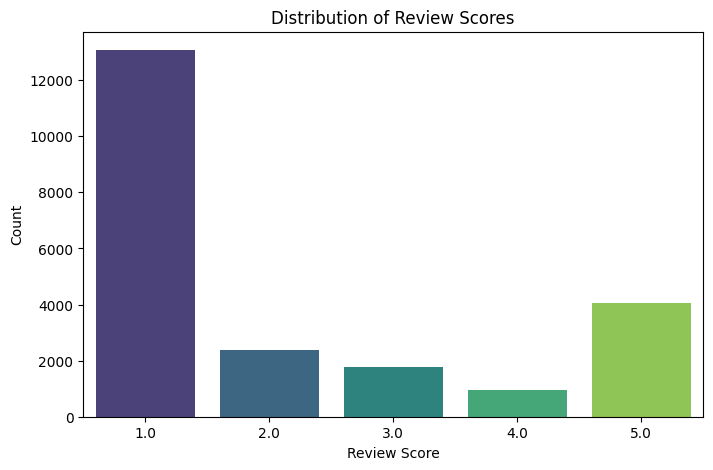

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_myxlrev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

# Review Length Analysis

In [26]:
df_myxlrev['length'] = df_myxlrev['content'].astype(str).apply(len)

df_myxlrev['length'].describe()

,length
count,22252.000000
mean,103.470160
std,99.433247
min,1.000000
25%,33.000000
50%,73.000000
75%,138.250000
max,500.000000


## 6. Review Trends Over Time
Analyzing how the number of reviews changes over time to detect patterns.

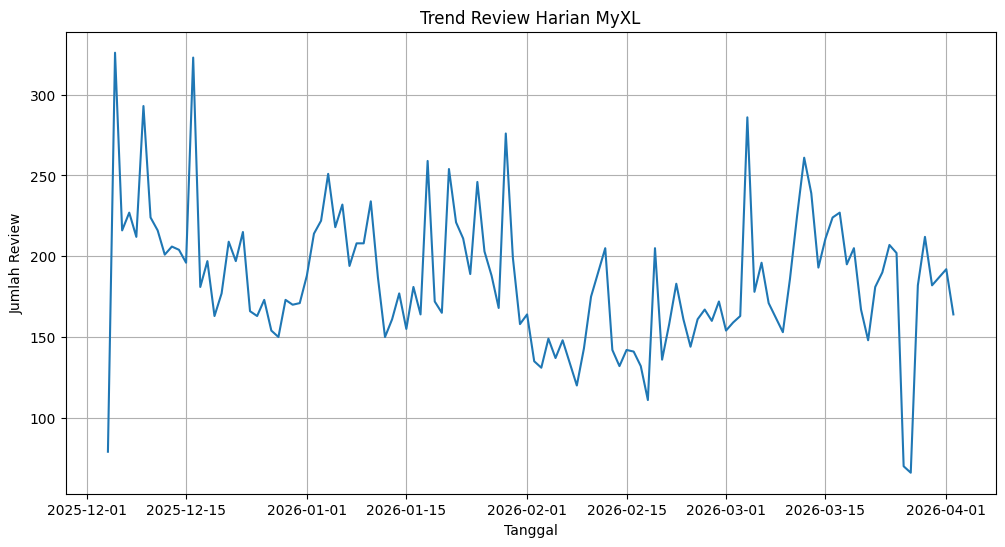

In [28]:
df_myxlrev['review_date'] = df_myxlrev['at'].dt.date
review_trend = df_myxlrev.groupby('review_date').size()

plt.figure(figsize=(12,6))
review_trend.plot()
plt.title("Trend Review Harian MyXL")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Review")
plt.grid(True)
plt.show()

# Word Frequency Analysis

In [27]:
## Word Frequency Analysis
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('indonesian'))

# Combine all review text
all_reviews = " ".join(df_myxlrev['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Most Common Words in Reviews:
        Word  Frequency
0         xl       8591
1        nya       5091
2      kuota       4893
3      paket       4377
4       beli       3877
5   jaringan       3807
6      mahal       3460
7     sinyal       3446
8         ga       3185
9        gak       3125
10  aplikasi       2816
11      udah       2528
12       aja       2269
13     pulsa       2205
14    tolong       2130
15        yg       2103
16    banget       1960
17     harga       1862
18     masuk       1798
19     jelek       1736
